# Case 2 - Longkanker en levenskwaliteit per land
**Team 11 - Minor Data Science**

## Onderzoeksvraag

> **Hangt roken samen met het stadium waarin longkanker wordt ontdekt, en is dat verband
> te verklaren door het land waar iemand woont?**

Waarom die tweede helft erbij staat: als rokers vaker een late diagnose krijgen, kan dat
ook komen doordat er meer gerookt wordt in landen met slechtere zorg. Om die verklaring te
kunnen toetsen koppelen we de patientgegevens aan indexcijfers per land.

Dit notebook doet de dataverzameling, de verkenning en de analyse.
Het dashboard in `app.py` gebruikt dezelfde stappen.

Bij elke codecel staat een blokje **Wat deze cel doet** met uitleg in gewone taal.


## Bronvermelding

| Bron | Waarvoor gebruikt |
|---|---|
| Kaggle: `laxmikantaroy/lung-cancer-risk-factors-and-survival-dataset` | patientgegevens longkanker |
| Kaggle: `marcelobatalhah/quality-of-life-index-by-country` | levenskwaliteit-indices per land |
| kagglehub-documentatie | `dataset_load()` om de data in het script op te halen |
| Claude (AI-assistent) | opzet van de opschoon- en koppelstappen, aangepast aan onze data |

De groep kan elke regel in dit notebook toelichten.


**Wat deze cel doet**

Haalt de vier gereedschappen binnen die we gebruiken:

- `pandas` - werken met tabellen (rijen en kolommen)
- `matplotlib.pyplot` - grafieken tekenen
- `kagglehub` - data ophalen bij Kaggle
- `KaggleDatasetAdapter` - vertelt kagglehub dat we een pandas-tabel terug willen

`as pd` en `as plt` zijn afkortingen, zodat je verderop `pd` kunt typen in plaats van
`pandas`. Dat is de gebruikelijke schrijfwijze.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter

## 1. Data verzamelen

De rubric eist dat de app de data zelf ophaalt via een openbare API, niet met de hand
gedownload. Dat is ook de reden dat iemand anders onze analyse kan herhalen: het adres
van de dataset staat in de code.

**Wat deze cel doet**

Downloadt twee datasets van Kaggle en zet ze in twee tabellen: `df_cancer` en `df_health`.

Per aanroep geef je drie dingen mee: dat je een pandas-tabel wilt, welke dataset (de
naam zoals die op Kaggle staat), en welk bestand daarbinnen.

`df_cancer.shape` geeft `(rijen, kolommen)` terug, zodat je meteen ziet of de download
gelukt is.

**Waarom dit zo kan:** deze datasets zijn openbaar, dus er is geen inlog of API-sleutel
nodig. Daardoor draait een schone clone van de repo zonder handmatige stappen - precies
wat de voorwaarden eisen.

In [2]:
df_cancer = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "laxmikantaroy/lung-cancer-risk-factors-and-survival-dataset",
    "lung_cancer_dataset.csv",
)

df_health = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "marcelobatalhah/quality-of-life-index-by-country",
    "quality_of_life_indices_by_country.csv",
)

print("kankerdata:", df_cancer.shape)
print("levenskwaliteit:", df_health.shape)

kankerdata: (2000, 46)
levenskwaliteit: (1495, 12)


## 2. Data verkennen

Voordat je iets berekent, kijk je of de data klopt. De rubric noemt drie checks:
ontbrekende waarden, bereik, en dubbele rijen.

**Wat deze cel doet**

Drie controles, elk op beide tabellen:

- `.isna()` markeert elke lege cel. De eerste `.sum()` telt per kolom, de tweede telt die
  aantallen bij elkaar op tot een totaal. Uitkomst 0 = niets ontbreekt.
- `.duplicated().sum()` telt rijen die exact hetzelfde zijn als een eerdere rij.
- `.min()` en `.max()` tonen de laagste en hoogste waarde, zodat je ziet of er onmogelijke
  getallen in zitten (een leeftijd van 200, een index van -5).

`\n` in een print zet er een lege regel boven, puur om de output leesbaar te houden.

In [3]:
print("ONTBREKENDE WAARDEN")
print("  kankerdata:", df_cancer.isna().sum().sum())
print("  levenskwaliteit:", df_health.isna().sum().sum())

print("\nDUBBELE RIJEN")
print("  kankerdata:", df_cancer.duplicated().sum())
print("  levenskwaliteit:", df_health.duplicated().sum())

print("\nBEREIK")
print("  rookjaren:", df_cancer["Pack_Years"].min(), "-", df_cancer["Pack_Years"].max())
print("  zorgindex:", df_health["Health Care Index"].min(), "-", df_health["Health Care Index"].max())
print("  vervuilingsindex:", df_health["Pollution Index"].min(), "-", df_health["Pollution Index"].max())

ONTBREKENDE WAARDEN
  kankerdata: 0
  levenskwaliteit: 0

DUBBELE RIJEN
  kankerdata: 0
  levenskwaliteit: 0

BEREIK
  rookjaren: 0.0 - 106.0
  zorgindex: 28.3 - 88.4
  vervuilingsindex: 11.5 - 96.6


**Wat deze cel doet**

Een inhoudelijke controle die verder gaat dan "is het veld gevuld": iemand die nooit heeft
gerookt, kan geen rookjaren hebben. De twee voorwaarden worden met `&` gecombineerd, en
`.sum()` telt hoe vaak die onmogelijke combinatie voorkomt.

Daarna tellen we de landen in beide tabellen en tonen we de landen met de minste
patienten.

**Waarom dit nodig is:** het verschil in aantal landen (60 tegenover 98) voorspelt dat er
bij het koppelen straks rijen wegvallen, en de kleinste landen bepalen waar we later onze
grens leggen.

In [4]:
# Logische check: wie nooit gerookt heeft, kan geen rookjaren hebben.
onmogelijk = ((df_cancer["Smoking_Status"] == "Never Smoked") & (df_cancer["Pack_Years"] > 0)).sum()
print("niet-rokers met rookjaren:", onmogelijk)

print("\nlanden in kankerdata:", df_cancer["Country"].nunique())
print("landen in levenskwaliteit:", df_health["Country"].nunique())
print("\npatienten per land - de 8 kleinste:")
print(df_cancer["Country"].value_counts().tail(8))

niet-rokers met rookjaren: 0

landen in kankerdata: 60
landen in levenskwaliteit: 98

patienten per land - de 8 kleinste:
Country
Morocco         13
Egypt           12
South Africa    12
Algeria         11
Ethiopia        11
Uganda          11
Tanzania        10
Nigeria          5
Name: count, dtype: int64


### Wat de verkenning opleverde

- **Geen ontbrekende waarden en geen dubbele rijen** in beide datasets. Alle rookjaren en
  indexwaarden liggen binnen een mogelijk bereik, en er zijn geen niet-rokers met
  rookjaren. Er valt dus niets op te schonen aan ontbrekende of onmogelijke waarden -
  dat schrijven we hier expliciet op, in plaats van een opschoonstap te verzinnen die
  niets doet.
- **De kankerdataset is waarschijnlijk synthetisch**: 2000 rijen, oplopende
  patientnummers (`LC-0001`...) en precies nul ontbrekende waarden komt in echte medische
  registraties niet voor. We gebruiken hem als oefenmateriaal en trekken geen conclusies
  over de echte wereld.
- **Twee dingen moeten wel opgeschoond**: landnamen die verschillen tussen de datasets,
  en de jaarkolom van de levenskwaliteit-data.

## 3. Opschonen

**Wat deze cel doet**

Twee reparaties.

**Landnamen.** `NAAM_FIX` is een vertaaltabel: links wat er staat, rechts wat het moet
worden. `.replace()` past alle drie in een keer toe.
*Waarom:* de kankerdata schrijft `UK`, de andere dataset `United Kingdom`. Zonder deze
stap ziet de computer dat als twee verschillende landen en vallen ze bij het koppelen weg.

**Jaarkolom.** De levenskwaliteit-data meet twee keer per jaar en noteert dat als tekst:
`'2015'` en `'2015/2'`. `.str[:4]` pakt de eerste vier tekens (`2015`), `.astype(int)`
maakt er een getal van. `groupby([...]).mean()` middelt daarna de twee halfjaarmetingen
tot een waarde per land per jaar.
*Waarom:* zonder dit heb je twee rijen per land per jaar, en dan zou het koppelen elke
patient verdubbelen.

In [5]:
NAAM_FIX = {"UK": "United Kingdom", "USA": "United States", "UAE": "United Arab Emirates"}
df_cancer["Country"] = df_cancer["Country"].replace(NAAM_FIX)

df_health["Jaar"] = df_health["Year"].str[:4].astype(int)
df_health = df_health.groupby(["Country", "Jaar"], as_index=False).mean(numeric_only=True)

print("levenskwaliteit na middelen:", df_health.shape)
print("jaren:", df_health["Jaar"].min(), "-", df_health["Jaar"].max())

levenskwaliteit na middelen: (781, 11)
jaren: 2015 - 2024


**Wat deze cel doet**

Gooit alle kolommen weg die we niet gebruiken, en geeft de rest Nederlandse namen.

De dubbele blokhaken `df[[...]]` betekenen: houd deze lijst kolommen over.
`.rename(columns={...})` hernoemt ze, met links de oude naam en rechts de nieuwe.

**Waarom:** de kankerdata heeft 46 kolommen en daar gebruiken we er 9 van. Minder kolommen
maakt de tabel leesbaar. En omdat beide tabellen nu `Land` en `Jaar` heten, wordt het
koppelen in de volgende cel een stuk eenvoudiger.

In [6]:
# Alleen de kolommen die we nodig hebben, met Nederlandse namen.
df_cancer = df_cancer[["Patient_ID", "Country", "Diagnosis_Year",
                       "Smoking_Status", "Pack_Years", "Cancer_Type",
                       "Cancer_Stage", "Survived", "Survival_Months"]]
df_cancer = df_cancer.rename(columns={
    "Patient_ID": "Patient",
    "Country": "Land",
    "Diagnosis_Year": "Jaar",
    "Smoking_Status": "Rookstatus",
    "Pack_Years": "Rookjaren",
    "Cancer_Type": "Kankersoort",
    "Cancer_Stage": "Stadium",
    "Survived": "Overleefd",
    "Survival_Months": "Overlevingsmaanden",
})

df_health = df_health[["Country", "Jaar", "Health Care Index", "Pollution Index"]]
df_health = df_health.rename(columns={
    "Country": "Land",
    "Health Care Index": "Zorgkwaliteit",
    "Pollution Index": "Luchtvervuiling",
})

df_cancer.head()

,Patient,Land,Jaar,Rookstatus,Rookjaren,Kankersoort,Stadium,Overleefd,Overlevingsmaanden
0,LC-0001,China,2020,Current Smoker,39.2,NSCLC,Stage IV,No,4
1,LC-0002,Mexico,2021,Former Smoker,8.5,NSCLC,Stage I,Yes,76
2,LC-0003,Japan,2017,Never Smoked,0.0,NSCLC,Stage I,No,69
3,LC-0004,Singapore,2018,Current Smoker,35.7,NSCLC,Stage IV,No,9
4,LC-0005,Malaysia,2024,Never Smoked,0.0,NSCLC,Stage III,Yes,5


## 4. Koppelen

Hier worden de twee bronnen een dataset. De rubric vraagt expliciet om de sleutel waarop
gejoined is, en het aantal rijen voor en na.

**Wat deze cel doet**

`merge` plakt de twee tabellen aan elkaar. De sleutel is `["Land", "Jaar"]`: een
patientrij krijgt de indexcijfers van zijn eigen land in zijn eigen diagnosejaar.

`how="inner"` betekent: houd alleen rijen die in beide tabellen voorkomen. Patienten uit
een land zonder indexcijfers vallen dus weg, en dat is precies wat de tellingen laten zien.

De laatste twee regels zoeken uit welke landen zijn afgevallen. `set(...)` maakt er
verzamelingen van, en met `-` vraag je: wat zit in de eerste maar niet in de tweede?

**Waarom op land EN jaar:** zou je alleen op `Land` koppelen, dan krijgt elke patient alle
meetjaren van zijn land achter elkaar geplakt en vermenigvuldig je je data. Dat is de
valkuil die de rubric noemt.

In [7]:
rijen_voor = len(df_cancer)

samen = df_cancer.merge(df_health, on=["Land", "Jaar"], how="inner")

print("patienten voor de join:", rijen_voor)
print("patienten na de join:  ", len(samen), "(", samen["Land"].nunique(), "landen )")
print("verloren:              ", rijen_voor - len(samen))
print("jaren in het resultaat:", samen["Jaar"].min(), "-", samen["Jaar"].max())

weggevallen = sorted(set(df_cancer["Land"]) - set(samen["Land"]))
print("\nlanden zonder levenskwaliteit-gegevens:", weggevallen)

patienten voor de join: 2000
patienten na de join:   1291 ( 48 landen )
verloren:               709
jaren in het resultaat: 2015 - 2024

landen zonder levenskwaliteit-gegevens: ['Algeria', 'Bhutan', 'Cuba', 'Ethiopia', 'Ghana', 'Iraq', 'Maldives', 'Myanmar', 'Nepal', 'Tanzania', 'Timor-Leste', 'Uganda']


De landen die wegvallen zijn vooral Afrikaanse en Zuid-Aziatische landen. Onze
conclusies gaan dus over relatief welvarende landen. Dat is een beperking, geen fout,
maar we benoemen hem.

**Wat deze cel doet**

Bepaalt welke landen genoeg patienten hebben voor de analyse OP LANDNIVEAU (deel 6c).

`value_counts()` telt hoeveel patienten elk land heeft. De regel eronder houdt de namen
over van landen die aan de grens voldoen. `.isin(genoeg)` filtert de tabel daarop.
`.copy()` maakt een echte kopie, zodat pandas niet gaat waarschuwen als we straks een
kolom toevoegen.

**Waarom 20:** bij 5 patienten verschuift een persoon het percentage met 20 procentpunt.
Dan zegt "60% laat ontdekt" niets. Bij 20 is dat 5 procentpunt, en dat is werkbaar.

**Waarom na de join en niet ervoor:** de join laat zelf ook rijen vallen. Zou je eerst
filteren, dan kan een land alsnog onder de 20 zakken zonder dat je het merkt.

**Waarom alleen voor 6c:** in deel 6a, 6b en 7 is elke *patient* een waarneming, en een
patient uit een klein land telt daar net zo goed mee als een patient uit Japan. Daar
gebruiken we dus `data` met alle 48 landen. Alleen in 6c is elk *land* een punt, en daar
zou een land met 5 patienten evenveel gewicht krijgen als een land met 62 - dat is waar de
ruis je correlatie onbruikbaar maakt.

In [8]:
MIN_PATIENTEN = 20

# Alle patienten blijven bewaard: dit is de tabel voor de analyses op patientniveau.
data = samen.copy()

# Alleen voor het landniveau houden we landen met genoeg patienten over.
telling = data["Land"].value_counts()
landen_genoeg = telling[telling >= MIN_PATIENTEN].index

print("patientniveau:", len(data), "patienten in", data["Land"].nunique(), "landen")
print("landniveau:   ", len(landen_genoeg), "landen met minstens", MIN_PATIENTEN, "patienten")

patientniveau: 1291 patienten in 48 landen
landniveau:    29 landen met minstens 20 patienten


## 5. Een afgeleide variabele

De rubric vraagt om minstens een variabele die je zelf afleidt uit de data.

**Wat deze cel doet**

Maakt twee nieuwe dingen.

**`Laat_stadium`**: `.isin([...])` kijkt per patient of het stadium III of IV is, en geeft
waar of niet waar terug.
*Waarom:* `Stadium` is tekst, daar kun je niet mee rekenen. Waar/niet-waar wel: het
gemiddelde van een kolom met waar en niet-waar is precies het aandeel "waar".

**`per_land`**: `groupby("Land")` zet alle patienten van een land bij elkaar, en `.agg()`
rekent per land een paar dingen uit - hoeveel patienten, welk deel laat ontdekt, en de
gemiddelde indexcijfers.

Let op wat hier gebeurt: voor deze cel is elke rij een **patient**, erna is elke rij een
**land**. Alles wat je daarna berekent gaat dus over landen, niet over mensen.

De laatste regel maakt van het aandeel (0,66) een percentage (66,0).

In [9]:
data["Laat_stadium"] = data["Stadium"].isin(["Stage III", "Stage IV"])

per_land = (data[data["Land"].isin(landen_genoeg)]
            .groupby("Land")
            .agg(patienten=("Patient", "count"),
                 pct_laat=("Laat_stadium", "mean"),
                 zorgkwaliteit=("Zorgkwaliteit", "mean"),
                 luchtvervuiling=("Luchtvervuiling", "mean"),
                 gem_rookjaren=("Rookjaren", "mean"))
            .reset_index())

per_land["pct_laat"] = (per_land["pct_laat"] * 100).round(1)
per_land.sort_values("zorgkwaliteit").head()

,Land,patienten,pct_laat,zorgkwaliteit,luchtvervuiling,gem_rookjaren
2,Bangladesh,25,56.0,42.566000,87.086000,7.884000
28,Vietnam,47,38.3,54.014894,85.931915,10.161702
3,Brazil,32,75.0,55.553125,56.201563,10.440625
19,Russia,37,59.5,57.794595,62.832432,9.402703
18,Poland,25,44.0,57.850000,55.422000,9.400000


## 6. Analyse

### 6a. Rookstatus en het stadium waarin de kanker wordt ontdekt

**Wat deze cel doet**

Berekent per rookstatus welk deel van de patienten pas laat werd ontdekt, en tekent dat
als staafdiagram.

`groupby("Rookstatus")["Laat_stadium"].mean()` splitst de patienten in drie groepen en
neemt per groep het gemiddelde van de waar/niet-waar-kolom - dat is het aandeel laat
ontdekt. Maal 100 maakt het een percentage.

`kind="barh"` tekent liggende staven, `sort_values()` zet ze op volgorde.
*Waarom liggend en gesorteerd:* de labels ("Current Smoker") passen dan naast de staaf, en
gesorteerd zie je de volgorde in een oogopslag.

percentage laat ontdekt (stadium III/IV):
Rookstatus
Current Smoker    66.5
Former Smoker     58.7
Never Smoked      37.7
Name: Laat_stadium, dtype: float64


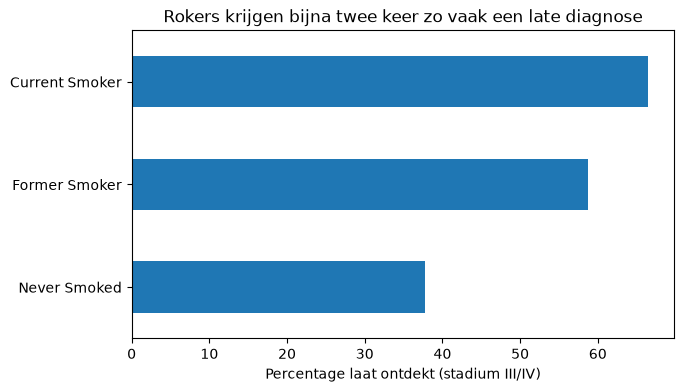

In [10]:
per_rookstatus = (data.groupby("Rookstatus")["Laat_stadium"].mean() * 100).round(1)
print("percentage laat ontdekt (stadium III/IV):")
print(per_rookstatus)

fig, ax = plt.subplots(figsize=(7, 4))
per_rookstatus.sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Percentage laat ontdekt (stadium III/IV)")
ax.set_ylabel("")
ax.set_title("Rokers krijgen bijna twee keer zo vaak een late diagnose")
plt.show()

### 6b. Waarom het stadium ertoe doet

Laat ontdekken is geen administratief detail: het hangt samen met of iemand het overleeft.
Deze stap verbindt de twee helften van het verhaal.

**Wat deze cel doet**

Rekent per stadium twee dingen uit: welk percentage overleefde, en hoeveel maanden mensen
gemiddeld leefden.

De eerste regel gebruikt een `lambda`: een mini-functie zonder naam. `(s == "Yes")` maakt
van de kolom waar/niet-waar, `.mean() * 100` maakt daar een percentage van.

*Waarom een lambda:* `Overleefd` bevat tekst ("Yes"/"No") en daar kan `.mean()` niet mee
overweg. Je moet het eerst omzetten, en dat doe je hier ter plekke.

In [11]:
overleving = data.groupby("Stadium").agg(
    pct_overleefd=("Overleefd", lambda s: (s == "Yes").mean() * 100),
    gem_maanden=("Overlevingsmaanden", "mean"),
).round(1)

print(overleving)

           pct_overleefd  gem_maanden
Stadium                              
Stage I             70.0         59.1
Stage II            50.3         35.7
Stage III           16.4         18.1
Stage IV             4.4          7.4


### 6c. De alternatieve verklaring

Het patroon uit 6a kan ook door iets anders komen dan roken. De meest voor de hand
liggende kandidaat is het land: misschien wordt kanker later ontdekt in landen met
slechtere zorg, en wordt daar toevallig ook meer gerookt. Daarvoor hebben we de
levenskwaliteit-data gekoppeld. We toetsen die verklaring hier.

**Wat deze cel doet**

Berekent drie correlaties en tekent een spreidingsdiagram.

`.corr()` geeft een getal tussen -1 en +1. Dicht bij 0 betekent geen samenhang, richting
+1 betekent: gaat de een omhoog, dan de ander ook. Richting -1 is het omgekeerde.

`ax.scatter()` zet elk land als punt neer. `nlargest(3, "pct_laat")` pakt de drie landen
met het hoogste percentage, en `annotate` zet hun naam erbij.

*Waarom maar drie namen:* zet je ze er alle 29 bij, dan is de grafiek onleesbaar. Je wilt
de uitschieters aanwijzen, niet alles labelen.

SAMENHANG OP LANDNIVEAU (correlatie)
  zorgkwaliteit vs pct laat ontdekt:   -0.107
  luchtvervuiling vs pct laat ontdekt: -0.03
  rookjaren vs pct laat ontdekt:       0.065


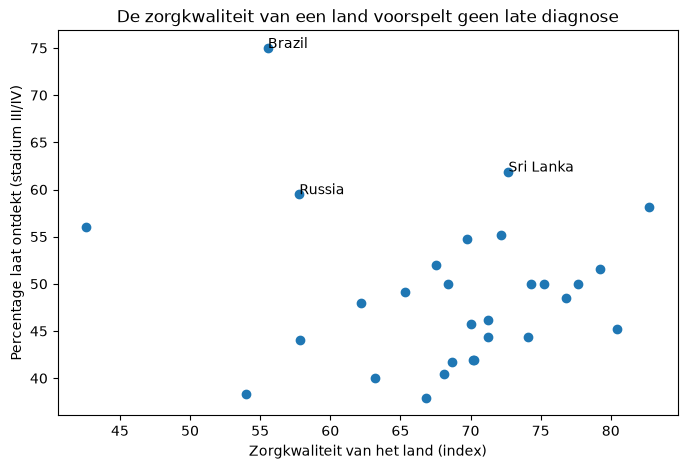

In [12]:
print("SAMENHANG OP LANDNIVEAU (correlatie)")
print("  zorgkwaliteit vs pct laat ontdekt:  ", round(per_land["pct_laat"].corr(per_land["zorgkwaliteit"]), 3))
print("  luchtvervuiling vs pct laat ontdekt:", round(per_land["pct_laat"].corr(per_land["luchtvervuiling"]), 3))
print("  rookjaren vs pct laat ontdekt:      ", round(per_land["pct_laat"].corr(per_land["gem_rookjaren"]), 3))

fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.scatter(per_land["zorgkwaliteit"], per_land["pct_laat"])

for _, r in per_land.nlargest(3, "pct_laat").iterrows():
    ax2.annotate(r["Land"], (r["zorgkwaliteit"], r["pct_laat"]))

ax2.set_xlabel("Zorgkwaliteit van het land (index)")
ax2.set_ylabel("Percentage laat ontdekt (stadium III/IV)")
ax2.set_title("De zorgkwaliteit van een land voorspelt geen late diagnose")
plt.show()

**Wat hier staat.** Alle drie de correlaties liggen vlak bij nul: -0,107 voor
zorgkwaliteit, -0,03 voor vervuiling en 0,065 voor rookjaren. In de spreidingsgrafiek zie
je hetzelfde: de punten vormen een wolk, geen lijn.

De alternatieve verklaring houdt dus geen stand. Landen met betere zorg ontdekken
longkanker niet eerder dan landen met slechtere zorg, en de vervuilingsindex hangt er
evenmin mee samen. Het verschil dat we in 6a vinden komt daarmee niet uit de landen waar
de patienten vandaan komen.

Een kanttekening bij deze uitspraak: de correlaties zijn berekend over 29 landen. Dat is
weinig, en een paar uitschieters kunnen zo'n getal verschuiven. "Wij vinden geen
aanwijzing voor een verband" is daarom een eerlijkere formulering dan "er is geen
verband".

### 6d. Twee verklaringen die je zou verwachten - en die het niet zijn

Het land verklaart het patroon niet. Twee andere kandidaten liggen voor de hand, en die
kunnen we binnen de kankerdata zelf toetsen door de groepen uit te splitsen.

**Kandidaat 1: rokers krijgen een andere kankersoort.** SCLC (kleincellig) groeit sneller
en zaait eerder uit dan NSCLC. Als rokers vaker SCLC hebben, zou dat hun late diagnoses
kunnen verklaren zonder dat het roken zelf iets doet.

**Wat deze cel doet**

Eerst: hoe zijn de kankersoorten verdeeld over de drie rookgroepen? `crosstab` met
`normalize="index"` rekent per rij naar percentages, zodat je de groepen kunt vergelijken
ook al zijn ze verschillend groot.

Daarna: het percentage late diagnoses per rookstatus, maar nu **binnen** elke kankersoort
apart. Dat heet uitsplitsen: je houdt de kankersoort gelijk en kijkt of het verschil tussen
rokers en niet-rokers dan nog bestaat.

*Waarom dit een toets is:* blijft het patroon binnen NSCLC even sterk, dan kan de
kankersoort het niet veroorzaakt hebben.

In [13]:
print("verdeling kankersoort per rookstatus (%)")
print((pd.crosstab(data["Rookstatus"], data["Kankersoort"], normalize="index") * 100).round(1))

print("\npercentage laat ontdekt, per rookstatus BINNEN elke kankersoort")
print((data.groupby(["Kankersoort", "Rookstatus"])["Laat_stadium"].mean() * 100).round(1))

verdeling kankersoort per rookstatus (%)
Kankersoort     NSCLC  SCLC
Rookstatus                 
Current Smoker   75.9  24.1
Former Smoker    94.4   5.6
Never Smoked     93.3   6.7

percentage laat ontdekt, per rookstatus BINNEN elke kankersoort
Kankersoort  Rookstatus    
NSCLC        Current Smoker    67.5
             Former Smoker     58.5
             Never Smoked      37.3
SCLC         Current Smoker    63.3
             Former Smoker     62.5
             Never Smoked      43.6
Name: Laat_stadium, dtype: float64


**Wat hier staat.** Rokers hebben inderdaad veel vaker SCLC: 24,1% tegen 5,6% bij
ex-rokers en 6,7% bij nooit-rokers. De kandidaat is dus reeel.

Maar hij verklaart het niet. Kijk je alleen naar NSCLC-patienten - dezelfde kankersoort
voor iedereen - dan blijft het patroon vrijwel onveranderd. Alle getallen hieronder zijn
**percentages laat ontdekt** (stadium III of IV), niet sterftecijfers:

| groep | alleen NSCLC | hele groep |
|---|---|---|
| huidige rokers | 67,5% | 66,5% |
| ex-rokers | 58,5% | 58,7% |
| nooit gerookt | 37,3% | 37,7% |

Binnen SCLC zie je hetzelfde verloop.

De kankersoort kan het verschil dus hooguit voor een klein deel verklaren.

**Kandidaat 2: rokers hebben een dodelijkere ziekte.** Rokers overleven vaker niet.
Maar komt dat doordat hun kanker gevaarlijker is, of alleen doordat hij later wordt
ontdekt? Dat scheiden we door de overleving per rookstatus te bekijken binnen elk
stadium apart.

**Wat deze cel doet**

Berekent het overlevingspercentage per rookstatus, eerst voor iedereen en daarna binnen elk
stadium apart.

*Wat je eruit afleest:* liggen de drie groepen binnen hetzelfde stadium dicht bij elkaar,
dan is de ziekte zelf niet dodelijker voor rokers. Het verschil in totale overleving komt
dan doordat rokers vaker in een hoger stadium binnenkomen - en dan is het stadium de
schakel tussen roken en overleven.

In [14]:
data["Overleefd_ja"] = data["Overleefd"] == "Yes"

print("overleving per rookstatus (alle patienten, %)")
print((data.groupby("Rookstatus")["Overleefd_ja"].mean() * 100).round(1))

print("\noverleving per rookstatus BINNEN elk stadium (%)")
print((data.groupby(["Stadium", "Rookstatus"])["Overleefd_ja"].mean() * 100).round(1))

overleving per rookstatus (alle patienten, %)
Rookstatus
Current Smoker    28.4
Former Smoker     31.5
Never Smoked      41.3
Name: Overleefd_ja, dtype: float64

overleving per rookstatus BINNEN elk stadium (%)
Stadium    Rookstatus    
Stage I    Current Smoker    60.5
           Former Smoker     74.2
           Never Smoked      70.8
Stage II   Current Smoker    65.3
           Former Smoker     42.9
           Never Smoked      46.2
Stage III  Current Smoker    16.2
           Former Smoker     20.5
           Never Smoked      15.3
Stage IV   Current Smoker     5.9
           Former Smoker      2.5
           Never Smoked       3.8
Name: Overleefd_ja, dtype: float64


**Let op: dit zijn percentages OVERLEEFD, geen sterftecijfers.** In 6a en 6c ging het
steeds om het percentage *laat ontdekt*; hier gaat het om wie het overleefde. Hoe hoger,
hoe beter.

**Wat hier staat.** Over alle patienten overleeft 28,4% van de rokers, 31,5% van de
ex-rokers en 41,3% van de nooit-rokers.

Splits je uit naar stadium, dan verdwijnt dat verschil bij de zware stadia:

| stadium | rokers | ex-rokers | nooit gerookt |
|---|---|---|---|
| III | 16,2% overleefd | 20,5% | 15,3% |
| IV | 5,9% overleefd | 2,5% | 3,8% |

De drie groepen liggen daar op elkaar. Een roker met stadium IV heeft ongeveer dezelfde
kans als een niet-roker met stadium IV - en die kans is voor iedereen klein.

Dat wijst het stadium aan als de schakel: rokers overleven niet minder vaak omdat hun
ziekte dodelijker is, maar omdat ze vaker in een hoger stadium binnenkomen.

**Wees hier voorzichtig met de cijfers van stadium I en II.** Daar springen de percentages
alle kanten op (60,5 / 74,2 / 70,8 en 65,3 / 42,9 / 46,2) en zijn rokers soms juist beter
af. Die groepen zijn klein en dat is ruis. De conclusie leunt op stadium III en IV, waar de
meeste patienten zitten.

## 7. Vergelijking over tijd

De rubric vraagt om een grafiek die twee periodes naast elkaar zet. We splitsen daarbij
op rookstatus, zodat de vergelijking iets toevoegt aan 6a in plaats van het te herhalen.

**Wat deze cel doet**

Deelt de patienten in twee periodes en vergelijkt die.

`.apply(lambda j: ...)` loopt door de jaartallen en geeft per patient een label:
2015-2019 of 2020-2024.

`groupby(["Periode", "Rookstatus"])` maakt zes groepen (twee periodes maal drie
rookstatussen). `.unstack()` draait dat om tot een tabel met periodes als rijen en
rookstatus als kolommen - dat is de vorm die `plot(kind="bar")` nodig heeft om de staven
naast elkaar te zetten.

*Waarom uitgesplitst naar rookstatus:* alleen twee periodes vergelijken geeft twee staven
en weinig verhaal. Met de uitsplitsing zie je of een verandering voor alle groepen geldt
of maar voor een.

Periode    Rookstatus    
2015-2019  Current Smoker    68.8
           Former Smoker     66.0
           Never Smoked      37.6
2020-2024  Current Smoker    65.0
           Former Smoker     54.4
           Never Smoked      37.7
Name: Laat_stadium, dtype: float64


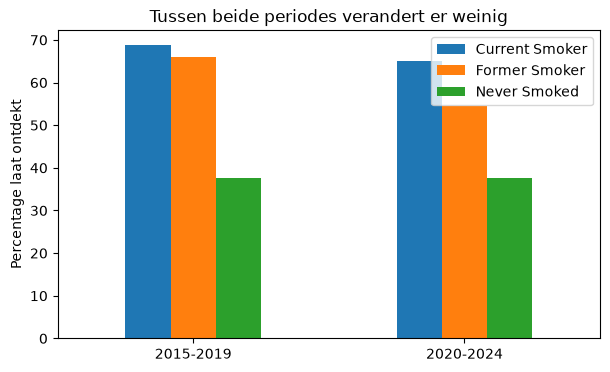

In [15]:
data["Periode"] = data["Jaar"].apply(lambda j: "2015-2019" if j <= 2019 else "2020-2024")

per_periode = (data.groupby(["Periode", "Rookstatus"])["Laat_stadium"].mean() * 100).round(1)
print(per_periode)

fig3, ax3 = plt.subplots(figsize=(7, 4))
per_periode.unstack().plot(kind="bar", ax=ax3)
ax3.set_ylabel("Percentage laat ontdekt")
ax3.set_xlabel("")
ax3.set_title("Tussen beide periodes verandert er weinig")
plt.xticks(rotation=0)
plt.legend(title="")
plt.show()

### Is die daling echt?

In de grafiek hierboven lijkt het percentage laat ontdekte gevallen bij ex-rokers te
dalen. Voordat we dat een bevinding noemen, toetsen we of zo'n verschil ook door toeval
kan ontstaan.

**Wat deze cel doet**

Voert een chi-kwadraattoets uit op de ex-rokers.

`crosstab` maakt een tabel van vier getallen: hoeveel ex-rokers per periode laat en hoeveel
vroeg werden ontdekt. `chi2_contingency` vergelijkt die met wat je zou verwachten als de
periode er niet toe deed.

De uitkomst is de **p-waarde**: de kans dat je een verschil van deze omvang meet terwijl er
in werkelijkheid niets aan de hand is. Onder 0,05 spreek je van een significant verschil.

*Waarom deze toets:* we tellen mensen in categorieen (laat/vroeg, periode 1/periode 2), en
daar is de chi-kwadraattoets voor bedoeld. Voor het vergelijken van gemiddelden zou je een
t-toets gebruiken.

*Let op bij het lezen:* een hoge p-waarde bewijst niet dat er geen verschil is. Het
betekent dat deze hoeveelheid data te klein is om er een aan te tonen.

In [16]:
from scipy import stats

ex_rokers = data[data["Rookstatus"] == "Former Smoker"]
tabel = pd.crosstab(ex_rokers["Periode"], ex_rokers["Laat_stadium"])
print(tabel)

chi2, p, _, _ = stats.chi2_contingency(tabel)
print("\naantal ex-rokers per periode:", list(tabel.sum(axis=1)))
print("p-waarde:", round(p, 3))
print("significant (p < 0.05)?", p < 0.05)

Laat_stadium  False  True 
Periode                   
2015-2019        18     35
2020-2024        41     49

aantal ex-rokers per periode: [53, 90]
p-waarde: 0.236
significant (p < 0.05)? False


**Wat hier staat.** Bij ex-rokers lijkt het aandeel late diagnoses te dalen van 66%
naar 54%. Maar die groep is klein - 53 en 90 patienten - en de toets geeft p = 0,236. Een
verschil van deze omvang ontstaat bij zulke aantallen dus regelmatig door toeval.

We behandelen die daling daarom als ruis, niet als een trend. Twee dingen versterken dat:
bij huidige rokers (69% naar 65%) en nooit-rokers (37,6% naar 37,7%) gebeurt er vrijwel
niets, terwijl een echte verandering in vroege opsporing juist alle groepen zou raken.

Let op de formulering: p = 0,236 bewijst niet dat er geen verandering is. Het betekent dat
deze hoeveelheid data te klein is om er een aan te tonen.

## 8. Conclusie

**Roken hangt samen met een late diagnose, en geen van de drie alternatieve
verklaringen die we konden toetsen verklaart dat weg.**

Van de huidige rokers krijgt 66,5% de diagnose pas in stadium III of IV. Bij ex-rokers is
dat 58,7% en bij mensen die nooit gerookt hebben 37,7% - bijna de helft minder dan bij
rokers. (Dit zijn percentages *laat ontdekt*, niet percentages overleden.) De drie groepen liggen ver uit elkaar en staan in dezelfde volgorde als hun
rookgeschiedenis.

**Dat verschil doet ertoe,** want het stadium bepaalt de afloop. Van de patienten met
stadium I *overleeft* 70%, van die met stadium IV nog 4,4%. De gemiddelde overleving daalt
van 59 maanden bij stadium I naar 7 maanden bij stadium IV. Later ontdekken is dus geen
registratiedetail maar het verschil tussen wel en niet overleven.

**Drie alternatieve verklaringen houden geen stand.**

*Het land.* Over 29 landen vinden we geen samenhang tussen het aandeel late diagnoses en de
zorgkwaliteit (-0,107), de vervuilingsindex (-0,03) of het gemiddeld aantal rookjaren
(0,065).

*De kankersoort.* Rokers hebben vaker de agressievere SCLC (24,1% tegen 5,6% en 6,7%), maar
binnen alleen NSCLC blijft het patroon staan: 67,5% / 58,5% / 37,3% laat ontdekt.

*Een dodelijkere ziekte.* Rokers overleven minder vaak (28,4% overleefd tegen 41,3%), maar
binnen hetzelfde stadium verdwijnt dat verschil: van de patienten met stadium IV overleeft
5,9% van de rokers, 2,5% van de ex-rokers en 3,8% van de nooit-rokers. Het stadium is dus
de schakel tussen roken en overleven, niet de ziekte zelf.

**Over tijd verandert er weinig.** Tussen 2015-2019 en 2020-2024 blijven de percentages
vrijwel gelijk. De enige zichtbare beweging zit bij ex-rokers (66% naar 54%), maar die
groep is te klein om daar iets over te zeggen: p = 0,236.

### Beperkingen

1. **De dataset is vrijwel zeker synthetisch.** 2000 rijen, oplopende patientnummers en
   nul ontbrekende waarden komen in echte medische registraties niet voor. Het gevonden
   verband tussen roken en stadium is medisch plausibel, maar deze data kan het niet
   aantonen - het is oefenmateriaal, geen bewijs.
2. **Er ontbreken landen.** Twaalf landen hebben geen levenskwaliteit-gegevens en vallen
   bij de koppeling weg, vooral Afrikaanse en Zuid-Aziatische. In de analyse op landniveau
   blijft geen enkel Afrikaans land over. Onze uitspraken gaan dus over Azie, Europa en
   Amerika.
3. **29 landen is weinig** voor een correlatie. We spreken daarom van "geen aanwijzing
   gevonden", niet van "aangetoond dat er geen verband is".
4. **Samenhang is geen oorzaak.** Dat rokers vaker laat worden ontdekt, betekent niet dat
   roken de late ontdekking veroorzaakt. Een even goede verklaring is dat rokers vaker
   klachten wegwuiven als "rokershoest" en daardoor later naar de dokter gaan. Met deze
   data kunnen we die twee niet uit elkaar halen.